In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

e:\python\Langgraph\myenv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class BMIState(TypedDict):
    weight: float
    height: float
    BMI: float
    category: str

In [3]:
def calculate_BMI(state : BMIState) -> BMIState:
    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    state['BMI'] = round(bmi, 2)
    return state


In [4]:
def label_BMI(state : BMIState) -> BMIState:
    bmi = state['BMI']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'
        
    return state

In [11]:
graph = StateGraph(BMIState)

# add notes to the graph
graph.add_node('calculate_BMI', calculate_BMI)
graph.add_node('label_BMI', label_BMI)

# add edges to the graph
graph.add_edge(START, 'calculate_BMI')
graph.add_edge('calculate_BMI', 'label_BMI')
graph.add_edge('label_BMI', END)

# compile the graph
workflow = graph.compile()





In [12]:
# excecute the graph
# when the wrorkflow is invoked we need to provide the initial state of the graph, which is a dictionary with the keys 'weight' and 'height'
# the workflow will return the final state of the graph, which is a dictionary with the keys 'weight', 'height' and 'BMI' 
# which return also a state
initial_state = {
    'weight': 70,
    'height': 1.8
}
output_State = workflow.invoke(initial_state)
print(output_State)

{'weight': 70, 'height': 1.8, 'BMI': 21.6, 'category': 'Normal weight'}


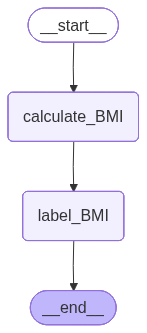

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())